In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns
from scipy import stats

In [2]:
np.random.seed(42)

In [3]:
def ecdf_xy(samples):
    x = np.sort(np.asarray(samples))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

# Question 1

## Parts 1-3

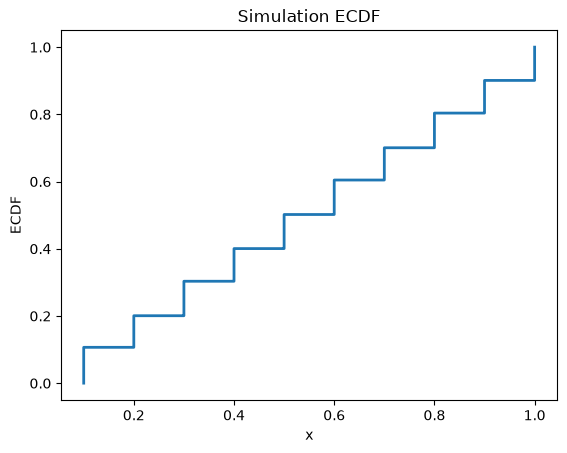

In [4]:
k = 10
grid = list(i/k for i in range(1, k + 1))

n = 5000
draws = []

for _ in range(n):
    draws.append(np.random.choice(grid))

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

## Part 4

Intuitively, as K becomes arbitraily large, our random variable can take on an arbitrary number of values between 0 and 1; each of these values has equal probability of being taken on but each of these probabilities becomes arbitrarily small. In the ECDF (with sufficiently large n), larger k manifests as an increasingly smooth line (because the width between steps becomes arbitrarily small). The fact that each value is equally likely results in roughly equal sized jumps (with sufficiently large n), but since the probability of any such value approaches zero, these jumps become arbitraily small. In the limit, this results in a line with slope 1--exactly the CDF of a uniform random variable with $a = 0$ and $b = 1$.

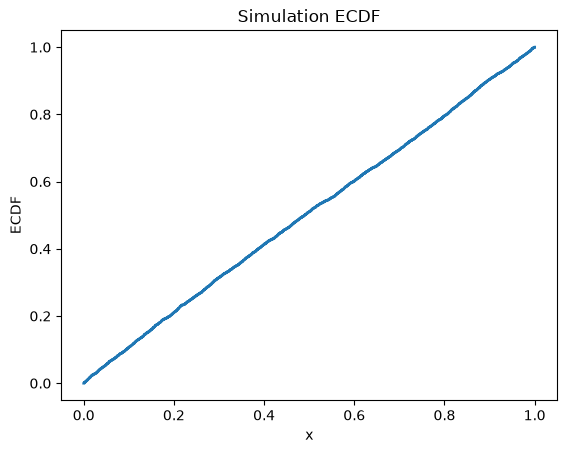

In [5]:
# Try with very small k
k = 100000
grid = list(i/k for i in range(1, k + 1))

n = 5000
draws = []

for _ in range(n):
    draws.append(np.random.choice(grid))

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

Mathematically, we know that $F(x) = 1$ for all $x >= 1$ and choices of n, and similarly $F(x) = 0$ for all $x <= 1$ and choices of n. Therefore, as n $\to \infty$, $F(x)$ approaches $1$ and $0$ in those respective regions. The more interesting part is proving the convergence of the middle region. For $0 <= x <= 1$, we have that 

$$
F(x) = \sum_{0}^{\lfloor{nx}\rfloor}\frac{1}{n} = \frac{\lfloor{nx}\rfloor + 1}{n}
$$

Now, we take the limit of $F(x)$ with respect to $n$:

$$
\lim_{n \to \infty}\frac{\lfloor{nx}\rfloor + 1}{n} = \lim_{n \to \infty}\frac{\lfloor{nx}\rfloor}{n} + \frac{1}{n}
$$






Observe that the second term goes to $0$. To evaluate the first term, note that $nx - 1 < \lfloor nx \rfloor \leq nx$ and that $x - \frac{1}{n} < \frac{\lfloor nx \rfloor}{n} \leq x$. The squeeze theorem gives that $\lim_{n \to \infty} \frac{\lfloor nx \rfloor}{n} = x$. 

All together, F(x) converges to the function:

$$
F(x) = \begin{cases} 
0 & \text{if } x < 0 \\
x & \text{if } 0 \leq x \leq 1 \\
1 & \text{if } x > 1 \\
\end{cases}
$$

But this is exactly the CDF of a uniform random variable on $[0,1]$.

# Question 2

## Parts 1-3

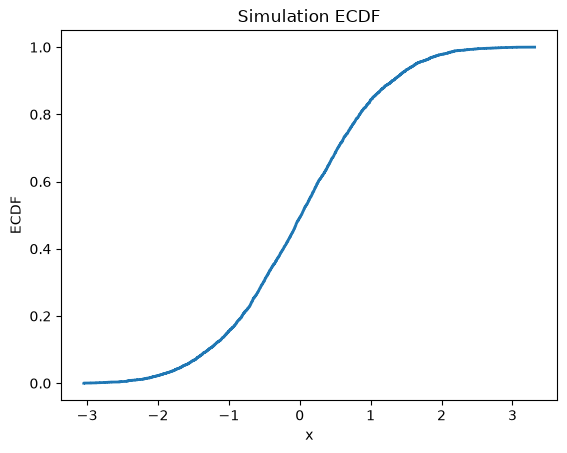

In [6]:
n = 32
b = 5000
draws = []


for _ in range(b):
    sample = stats.uniform.rvs(
    loc=-np.sqrt(3),
    scale=2*np.sqrt(3),
    size=n
)

    draws.append(np.mean(sample) * np.sqrt(n))


x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()


## Part 4

Visually, this appears to be the CDF of a standard normal random variable, and this makes sense. Moreover, the CLT gives that as n increases $\frac{\bar{X} - \mu}{\frac{\sigma}{\sqrt{n}}}$ tends in distribution to $N(0, 1)$. In this case, with $\mu = 0$ and $\sigma = 1$, the standardized variable simplifies to $\frac{\bar{X} - \mu}{\frac{\sigma}{\sqrt{n}}} = \sqrt{n}\bar{X}$. But notice this is exactly the value we were computing on each trial, meaning we are plotting the empirical CDF of a random variable who is tending to a standard normal random variable. Thus, since the empirical CDF approximates the true CDF, it should be converging to the CDF of a standard normal random variable.

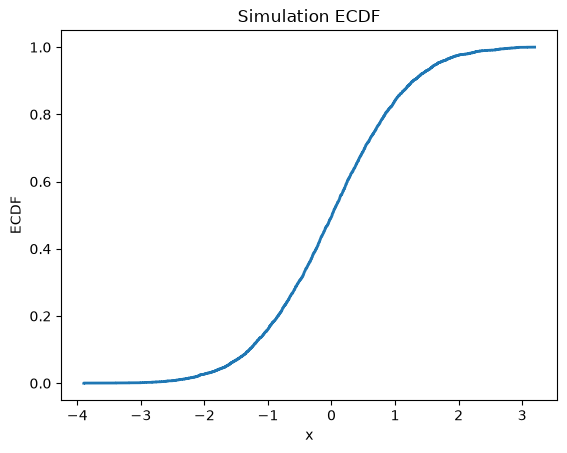

In [7]:
n = 6000
b = 5000
draws = []


for _ in range(b):
    sample = stats.uniform.rvs(
    loc=-np.sqrt(3),
    scale=2*np.sqrt(3),
    size=n
)

    draws.append(np.mean(sample) * np.sqrt(n))


x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

As anticipated, this is almost exactly the CDF of a standard normal random variable. 

# Question 3

## Parts 1 - 4

In [8]:
b = 5000
n = 40
p = 0.5

draws = []

for _ in range(b):
    cnt = 0

    for _ in range(n):
        cnt += np.random.choice([0, 1], p= [1 - p, p])

    draws.append(cnt)

draws = np.array(draws)
draws = (draws - n * p) / (np.sqrt(n * p * (1- p)))
    

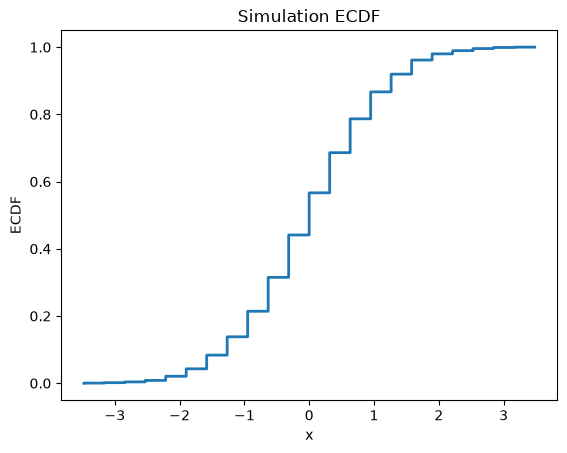

In [9]:
x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

## Part 5

As with the previous question, this appears like a very rough standard normal distribution. If we increase n (below), though, we see that the distribution begins to smooth out and appear more normal. 

We can understand the procedure above as a sum of independent Bernoulli trials (with parameter $p$) on each trial; denote this as $S_n$. The CLT, as applied to the Bernoulli random variable, gives that as n increases $\frac{\bar{X} - \mu}{\frac{\sigma}{\sqrt{n}}}$ tends in distribution to $N(0, 1)$. Notice that we can multiply by $1 = n/n$, which does not change our standardized variable, but reframes it as $\frac{S_n - n\mu}{\sqrt{n}\sigma} \sim N(0, 1)$. Plugging in $\mu = p$ and $\sigma = \sqrt{p(1-p)}$, we get $\frac{S_n - np}{\sqrt{np(1-p)}} \sim N(0, 1)$. But this is exactly the random variable whose CDF we were empirically approximating. Thus, the empirical CDF should be converging to the CDF of a standard normal random variable.

Interesting observation. While the CLT usually provides us with information about the limiting shape of a sampling distribution with $n$ samples, the sampling distribution of $n$ Bernoulli trials with parameter $p$ is actually a binomial random variable with parameters $n$ and $p$. That is, for sufficiently large n, the CLT tells us that the standardized binomial random variable may be approximated by the standard normal distribution (we can also "unnormalize" this random variable to get an approximate distribution for the original binomial random variable). This result only works because a binomial random variable can be decomposed into independent and identically distributed Bernoulli trials, which we may apply CLT to as above.

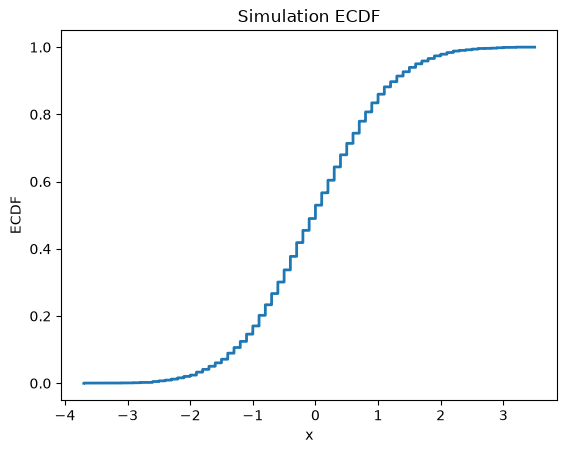

In [10]:
b = 5000
n = 400
p = 0.5

draws = []

for _ in range(b):
    cnt = 0

    for _ in range(n):
        cnt += np.random.choice([0, 1], p= [1 - p, p])

    draws.append(cnt)

draws = np.array(draws)
draws = (draws - n * p) / (np.sqrt(n * p * (1- p)))

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

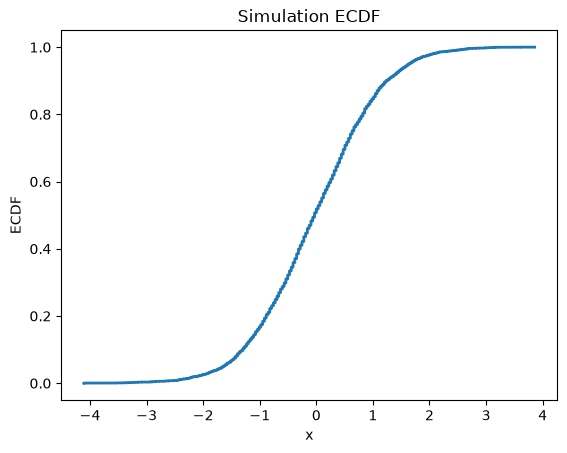

In [11]:
b = 5000
n = 4000
p = 0.5

draws = []

for _ in range(b):
    cnt = 0

    for _ in range(n):
        cnt += np.random.choice([0, 1], p= [1 - p, p])

    draws.append(cnt)

draws = np.array(draws)
draws = (draws - n * p) / (np.sqrt(n * p * (1- p)))

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

## Part 6

As seen below, varying $p$ does not affect ultimate convergence, but it does delay it. To understand why, note that a $p = 0.5$ provides us the most symmetric distribution for our underlying Bernoulli trial; the notion of symmetry may seem awkward in this context, where a random variable can take on only two values. However, as we shift $p$ in either direction, the distribution becomes increasingly skewed; it becomes increasingly common to achieve one (in the event that $p$ approaches $1$) and increasingly common to achieve zero (in the event that $p$ approaches $0$). While the CLT applies to any distribution, regardless of its original shape, its claim is about a limit, though we abuse this in practice. Indeed, we never take samples large enough to approach infinity, but, if we take them large enough, the sampling distribution usually converges enough for our applications. It can be shown that the rate of convergence is largely driven by the shape of the underlying distribution. If our distribution is highly skewed, then it will take longer for "averaging" to normalize the sampling distribution. This is exactly why we see $p = 0.01$ take comparatively longer to begin to look like the normal CDF. 

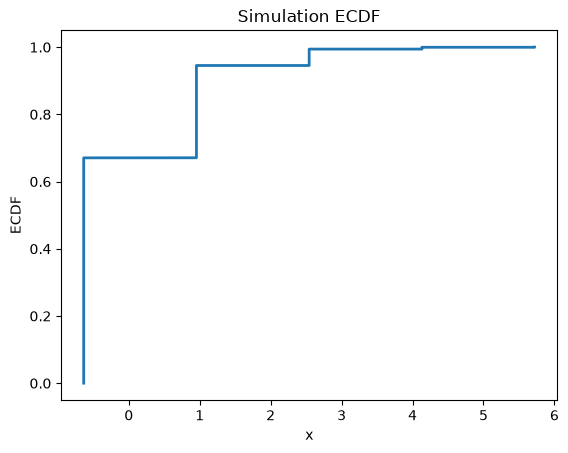

In [12]:
b = 5000
n = 40
p = 0.01

draws = []

for _ in range(b):
    cnt = 0

    for _ in range(n):
        cnt += np.random.choice([0, 1], p= [1 - p, p])

    draws.append(cnt)

draws = np.array(draws)
draws = (draws - n * p) / (np.sqrt(n * p * (1- p)))

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

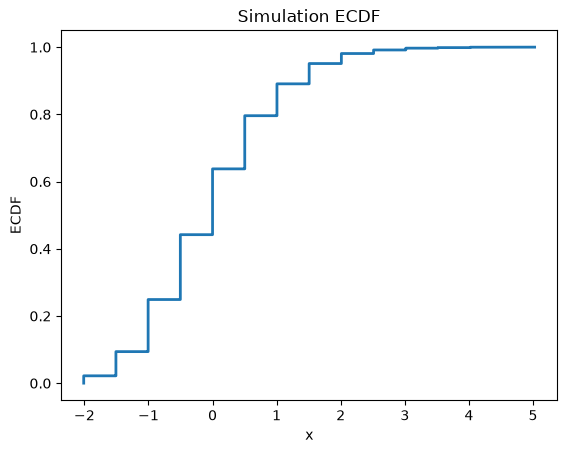

In [13]:
b = 5000
n = 400
p = 0.01

draws = []

for _ in range(b):
    cnt = 0

    for _ in range(n):
        cnt += np.random.choice([0, 1], p= [1 - p, p])

    draws.append(cnt)

draws = np.array(draws)
draws = (draws - n * p) / (np.sqrt(n * p * (1- p)))

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

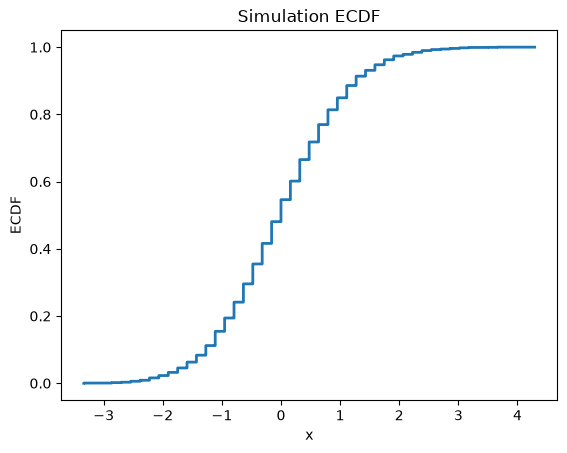

In [14]:
b = 5000
n = 4000
p = 0.01

draws = []

for _ in range(b):
    cnt = 0

    for _ in range(n):
        cnt += np.random.choice([0, 1], p= [1 - p, p])

    draws.append(cnt)

draws = np.array(draws)
draws = (draws - n * p) / (np.sqrt(n * p * (1- p)))

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

# Question 4

Note that our inner loop is exactly describing a geometric process, where periods represent independent Bernoulli trials, and we are interested in knowing the period with the first success; this can be quickly computed using np.random.geometric. In the spirit of the lab, I will only resort to the latter strategy as $p$ gets too small.

## Parts 1 to 3

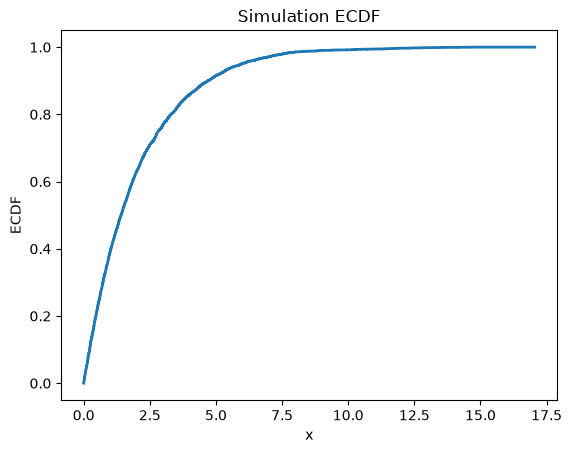

In [15]:
r = 0.5
dt = 0.001
n = 5000
p = r * dt
draws = []

for _ in range(n):
    first_success = 1

    while True:
        roll = np.random.choice([0, 1], p= [1 - p, p])

        if roll:
            draws.append(first_success)
            break

        first_success += 1

draws = np.array(draws)
draws = draws * dt

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

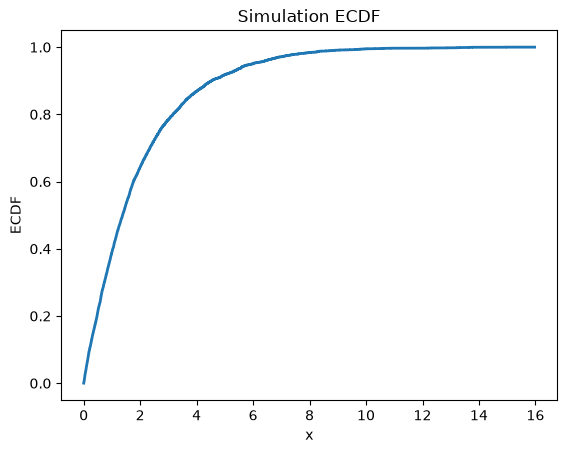

In [16]:
r = 0.5
dt = 0.0000001
n = 5000
p = r * dt
draws = []

draws = np.random.geometric(p=r * dt, size=n)
draws = draws * dt

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

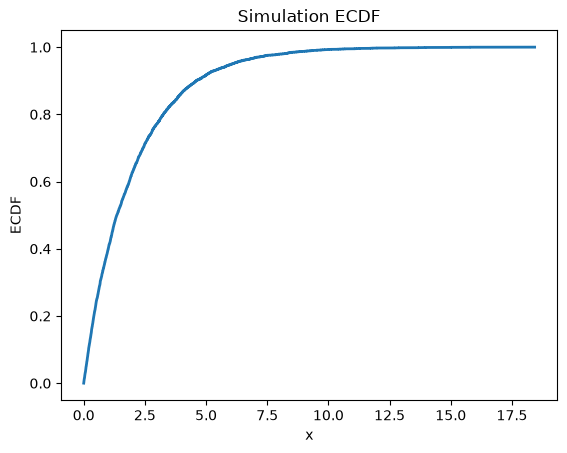

In [17]:
r = 0.5
dt = 0.000000000001
n = 5000
p = r * dt
draws = []

draws = np.random.geometric(p=r * dt, size=n)

draws = draws * dt

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

## Parts 4 and 5

As $dt$ approaches zero, we see that this empirical CDF, which approximates the true CDF, looks very similar to an exponential CDF. We can confirm that the true CDF converges to an exponential CDF with the following argument.


As mentioned previously, we are interested with the limiting behavior of a random variable $N = Xdt$, where $X$ is a geometric random variable with parameter $p = rdt$ and $dt$ is some constant that we are limiting upon. Explicitly, we are interested in $\lim_{dt \to 0}F_N(k)$.


First, note that $F_N(k) = 0$ for all $k < 0$ regardless of our choice of $dt$, which agrees with any exponential CDF. Also, note that $\lim_{dt \to 0}F_N(k) = \lim_{dt \to 0}P(N <= k) = 1 - \lim_{dt \to 0}P(N > k)$. It will be easier to find $\lim_{dt \to 0}P(N>K)$. 


To do so, we have $P(N > k) = P(dtX > k) = P(X > \frac{k}{dt})$. Now, for any geometric random variable, the set $\{X > t\}$ describes exactly the outcomes where we get a failure on the first $t$ trials. Thus, $\lim_{dt \to 0}P(X > \frac{k}{dt}) = \lim_{dt \to 0}(1 - rdt)^{\frac{k}{dt}}$


We can then manipulate this value into a classic limit. Setting $n = \frac{1}{dt}$, we have $\lim_{dt \to 0}(1 - rdt)^{\frac{k}{dt}} = \lim_{n \to \infty}(1 - \frac{r}{n})^{kn}$. This is exactly Euler's generalized limit, which evaluates to $e^{-rk}$. Thus, $\lim_{dt \to 0}F_N(k) = 1 - e^{-rk}$. Coupled with our discussion of what happens for $k<0$, this is exactly an exponential distribution with parameter $r$. 



Based on the derivation in the previous chunk, we can see that modifying r will not change the family of distribution which our empirical CDF will converge to, but it will shape the parameter r, which will affect the exact shape:

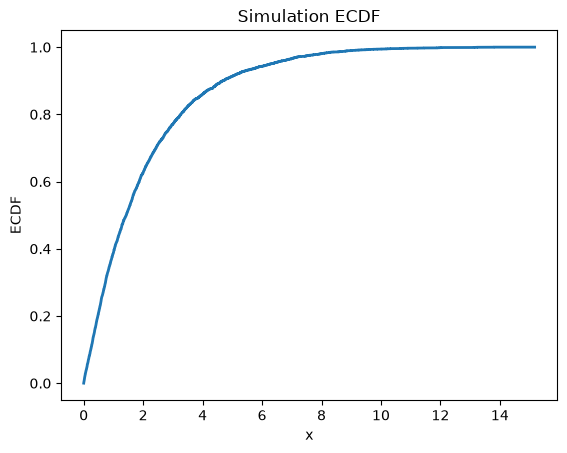

In [18]:
r = 0.5
dt = 0.000000000001
n = 5000
p = r * dt
draws = []

draws = np.random.geometric(p=r * dt, size=n)

draws = draws * dt

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

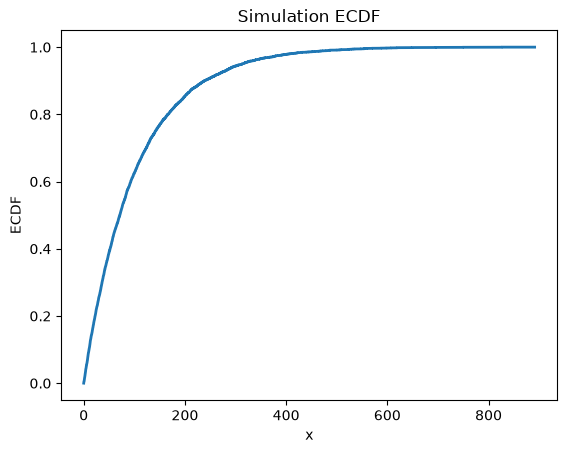

In [19]:
r = 0.01
dt = 0.000000000001
n = 5000
p = r * dt
draws = []

draws = np.random.geometric(p=r * dt, size=n)

draws = draws * dt

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

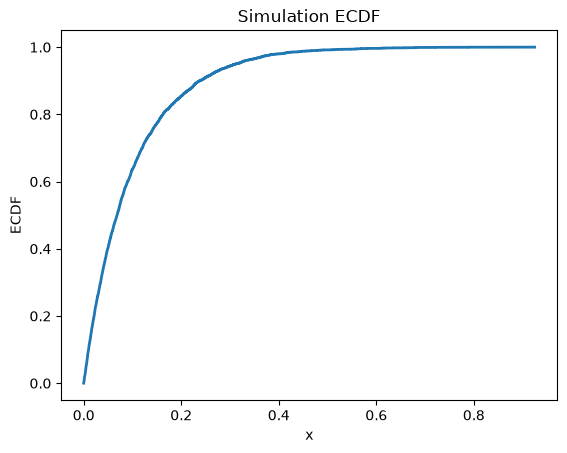

In [20]:
r = 10
dt = 0.000000000001
n = 5000
p = r * dt
draws = []

draws = np.random.geometric(p=r * dt, size=n)

draws = draws * dt

x, y = ecdf_xy(draws)

plt.step(x, y, lw=2)
plt.xlabel("x")
plt.ylabel("ECDF")
plt.title("Simulation ECDF")
plt.show()

For the exponential distribution, the rate parameter is inversely related to our expectation of how long survival should be. So, while all of the three visuals above have the same characteristic shape, their x axis varies drastically; the ECDF of $r = 0.01$ begins to converge to $1$ only at about $x=500$, whereas the ECDF of $r = 10$ begins to similarly converge by $x= 0.4$.